# Feature Relevance Analysis
This notebook evaluates the predictive relevance of both original and engineered features to support our feature engineering decisions.

We cover:
1. Correlation of raw features with the Outcome variable
2. Feature importance ranking from a temporary Random Forest model
3. Comparison of original vs. engineered features
4. Discussion of weak features (particularly Insulin)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier

## 1. Load Raw and Processed Data

In [2]:
# Raw data (before preprocessing)
raw_df = pd.read_csv('../data/diabetes.csv')
print(f'Raw dataset: {raw_df.shape}')
print(f'Columns: {list(raw_df.columns)}')
print()

# Processed data
X_train = pd.read_csv('../data/X_train.csv')
y_train = pd.read_csv('../data/y_train.csv').values.ravel()
print(f'Processed training set: {X_train.shape}')
print(f'Columns: {list(X_train.columns)}')

Raw dataset: (768, 9)
Columns: ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']

Processed training set: (536, 11)
Columns: ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'BMI_Category', 'BP_Range', 'Glucose_Insulin_Ratio']


## 2. Correlation of Raw Features with Outcome
We start by looking at how each original feature in the raw dataset correlates with the diabetes outcome.

Correlation with Outcome (raw features):
Glucose                     0.466581
BMI                         0.292695
Age                         0.238356
Pregnancies                 0.221898
DiabetesPedigreeFunction    0.173844
Insulin                     0.130548
SkinThickness               0.074752
BloodPressure               0.065068



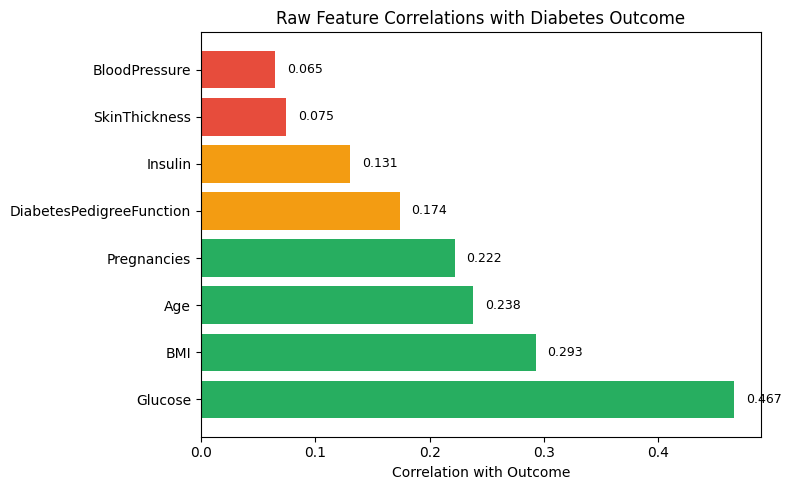

Green = strong (>0.2), Orange = moderate (0.1-0.2), Red = weak (<0.1)


In [3]:
raw_corr = raw_df.corr()['Outcome'].drop('Outcome').sort_values(ascending=False)

print('Correlation with Outcome (raw features):')
print(raw_corr.to_string())
print()

fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#27ae60' if v > 0.2 else '#f39c12' if v > 0.1 else '#e74c3c' for v in raw_corr.values]
bars = ax.barh(raw_corr.index, raw_corr.values, color=colors)
ax.set_xlabel('Correlation with Outcome')
ax.set_title('Raw Feature Correlations with Diabetes Outcome')
ax.axvline(x=0, color='black', linewidth=0.5)
for bar, val in zip(bars, raw_corr.values):
    ax.text(val + 0.01 if val > 0 else val - 0.04, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

print('Green = strong (>0.2), Orange = moderate (0.1-0.2), Red = weak (<0.1)')

## 3. Full Correlation Heatmap

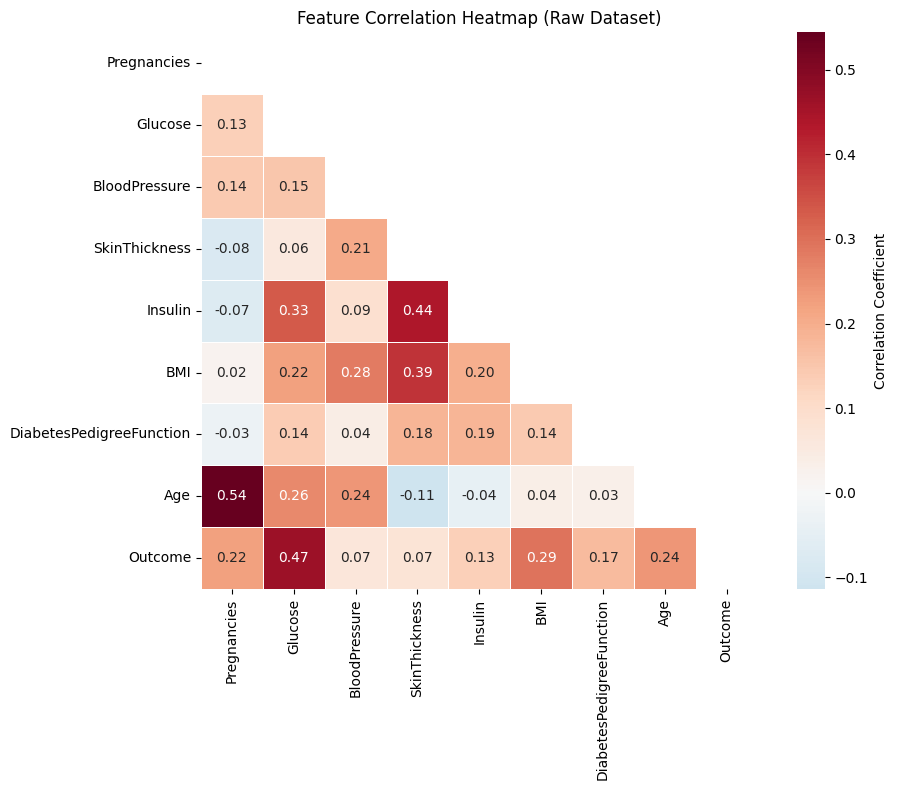

In [4]:
fig, ax = plt.subplots(figsize=(10, 8))
corr_matrix = raw_df.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, square=True, ax=ax, linewidths=0.5,
            cbar_kws={'label': 'Correlation Coefficient'})
ax.set_title('Feature Correlation Heatmap (Raw Dataset)')
plt.tight_layout()
plt.show()

## 4. Feature Importance from Random Forest
We train a temporary Random Forest on the processed training data to rank features by importance.

Feature Importance Ranking (Random Forest):
  1. Glucose: 0.2483
  2. Age: 0.1301
  3. BMI: 0.1248
  4. DiabetesPedigreeFunction: 0.0989
  5. Glucose_Insulin_Ratio: 0.0916  [ENGINEERED]
  6. Insulin: 0.0854
  7. SkinThickness: 0.0621
  8. Pregnancies: 0.0612
  9. BloodPressure: 0.0573
  10. BMI_Category: 0.0261  [ENGINEERED]
  11. BP_Range: 0.0141  [ENGINEERED]



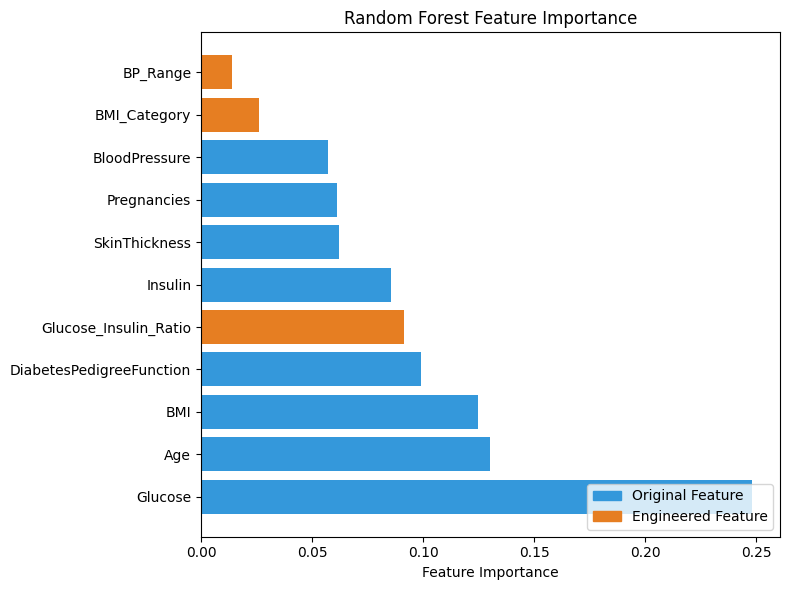

In [5]:
# Train a temporary RF model for feature importance
temp_rf = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42, n_jobs=-1)
temp_rf.fit(X_train, y_train)

importances = pd.Series(temp_rf.feature_importances_, index=X_train.columns).sort_values(ascending=False)

print('Feature Importance Ranking (Random Forest):')
for i, (feat, imp) in enumerate(importances.items(), 1):
    marker = '  [ENGINEERED]' if feat in ['BMI_Category', 'BP_Range', 'Glucose_Insulin_Ratio'] else ''
    print(f'  {i}. {feat}: {imp:.4f}{marker}')

print()

fig, ax = plt.subplots(figsize=(8, 6))
colors = ['#e67e22' if feat in ['BMI_Category', 'BP_Range', 'Glucose_Insulin_Ratio'] else '#3498db'
          for feat in importances.index]
ax.barh(importances.index, importances.values, color=colors)
ax.set_xlabel('Feature Importance')
ax.set_title('Random Forest Feature Importance')

# Legend
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color='#3498db', label='Original Feature'),
                    Patch(color='#e67e22', label='Engineered Feature')],
          loc='lower right')
plt.tight_layout()
plt.show()

## 5. Original vs. Engineered Features
Compare the predictive contribution of original features against our engineered ones.

Total importance from original features:    0.8682
Total importance from engineered features:  0.1318
Engineered feature share: 13.2%



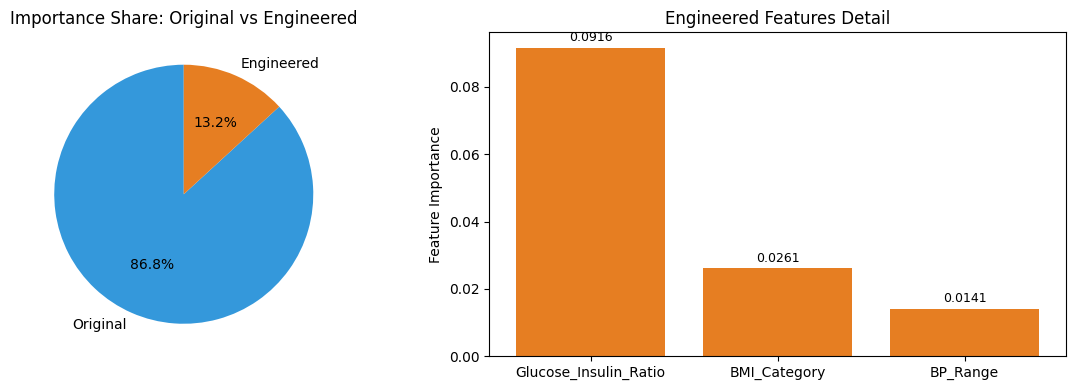

In [6]:
original_features = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
                      'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']
engineered_features = ['BMI_Category', 'BP_Range', 'Glucose_Insulin_Ratio']

orig_importance = importances[importances.index.isin(original_features)].sum()
eng_importance = importances[importances.index.isin(engineered_features)].sum()

print(f'Total importance from original features:    {orig_importance:.4f}')
print(f'Total importance from engineered features:  {eng_importance:.4f}')
print(f'Engineered feature share: {eng_importance / (orig_importance + eng_importance) * 100:.1f}%')
print()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Pie chart of total importance
ax1.pie([orig_importance, eng_importance],
        labels=['Original', 'Engineered'],
        colors=['#3498db', '#e67e22'],
        autopct='%1.1f%%', startangle=90)
ax1.set_title('Importance Share: Original vs Engineered')

# Side by side comparison
eng_detail = importances[importances.index.isin(engineered_features)]
ax2.bar(eng_detail.index, eng_detail.values, color='#e67e22')
ax2.set_ylabel('Feature Importance')
ax2.set_title('Engineered Features Detail')
for i, (feat, val) in enumerate(eng_detail.items()):
    ax2.text(i, val + 0.002, f'{val:.4f}', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

## 6. Discussion of Weak Features: Insulin
The Insulin feature is notable for having the most missing data (~48% zeros in the raw dataset) and relatively low predictive power.

Insulin zero values: 374 out of 768 (48.7%)
Insulin correlation with Outcome: 0.1305
Insulin RF importance rank: 6 of 11



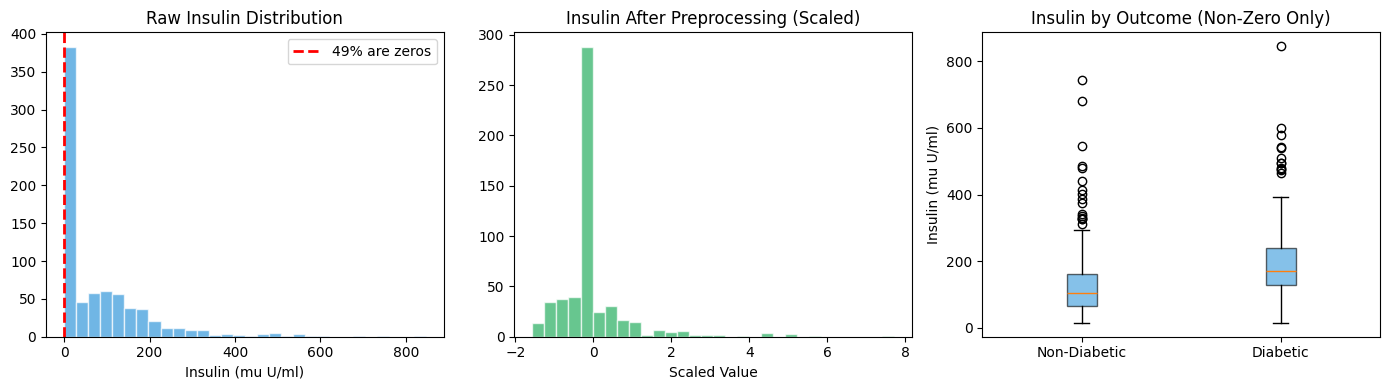

Despite being a weak standalone predictor due to missing data,
Insulin contributes to the engineered Glucose_Insulin_Ratio feature,
which captures insulin resistance patterns more effectively.


In [8]:
# Show Insulin's issues in the raw data
insulin_zeros = (raw_df['Insulin'] == 0).sum()
insulin_zero_pct = insulin_zeros / len(raw_df) * 100

print(f'Insulin zero values: {insulin_zeros} out of {len(raw_df)} ({insulin_zero_pct:.1f}%)')
print(f'Insulin correlation with Outcome: {raw_df["Insulin"].corr(raw_df["Outcome"]):.4f}')
print(f'Insulin RF importance rank: {list(importances.index).index("Insulin") + 1} of {len(importances)}')
print()

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Distribution with zeros highlighted
axes[0].hist(raw_df['Insulin'], bins=30, color='#3498db', edgecolor='white', alpha=0.7)
axes[0].axvline(x=0, color='red', linestyle='--', linewidth=2, label=f'{insulin_zero_pct:.0f}% are zeros')
axes[0].set_title('Raw Insulin Distribution')
axes[0].set_xlabel('Insulin (mu U/ml)')
axes[0].legend()

# After imputation (from processed data - unscaled would be better but we show scaled)
axes[1].hist(X_train['Insulin'], bins=30, color='#27ae60', edgecolor='white', alpha=0.7)
axes[1].set_title('Insulin After Preprocessing (Scaled)')
axes[1].set_xlabel('Scaled Value')

# Insulin by outcome
non_zero_insulin = raw_df[raw_df['Insulin'] > 0]
axes[2].boxplot([non_zero_insulin[non_zero_insulin['Outcome']==0]['Insulin'],
                 non_zero_insulin[non_zero_insulin['Outcome']==1]['Insulin']],
                tick_labels=['Non-Diabetic', 'Diabetic'],
                patch_artist=True,
                boxprops=dict(facecolor='#3498db', alpha=0.6))
axes[2].set_title('Insulin by Outcome (Non-Zero Only)')
axes[2].set_ylabel('Insulin (mu U/ml)')

plt.tight_layout()
plt.show()

print('Despite being a weak standalone predictor due to missing data,')
print('Insulin contributes to the engineered Glucose_Insulin_Ratio feature,')
print('which captures insulin resistance patterns more effectively.')

## 7. Summary

**Key Findings:**

- **Glucose** is the single strongest predictor of diabetes outcome, both by correlation (0.47) and by Random Forest feature importance.
- **BMI** and **Age** are the next most important features.
- **Insulin** is a weak predictor due to ~48% missing data. However, it contributes to the **Glucose_Insulin_Ratio** engineered feature which better captures insulin resistance.
- **SkinThickness** and **BloodPressure** have relatively low predictive relevance.
- The three **engineered features** (BMI_Category, BP_Range, Glucose_Insulin_Ratio) provide additional predictive signal, with Glucose_Insulin_Ratio being the most valuable of the three.

**Conclusion:** The feature engineering decisions are supported by the data. The engineered features add meaningful predictive value, and the weak features (Insulin, SkinThickness) are retained because they still contribute some information and because the dataset is small enough that removing features risks losing signal.